## **IMPORTS**

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy torch scikit-learn matplotlib scipy tabulate tqdm

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from tabulate import tabulate

#get parent folder wrt the notebooks folder
PROJECT_ROOT = Path.cwd().parent 
sys.path.append(str(PROJECT_ROOT))
#Import metrics
from src.metrics import ema_advantage_per_drift, slope_initial_window, convergence_speed_per_drift


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## **RESULT SETS LOADING**

In [2]:
DATA_PATH = '../results'

clstm = np.load(f'{DATA_PATH}/cLSTM_results_Adam.npz')
cgru  = np.load(f'{DATA_PATH}/cGRU_results_Adam.npz')

## **METRIC FUNCTIONS**
The functions used in the training notebooks are imported from the py files, while these presented are new ones which will be useful to compare the models' results.

In [3]:
# Compute the first sample index where rolling kappa enters a stable region above the threshold.
# Defines "stable convergence" as kappa remaining at or above `threshold` for at least
# `stability_window` consecutive samples. Returns the index where that stable region begins,
# or None if no such region exists within the segment.
    
# This is a stricter notion of convergence than TTP (Time-To-Threshold), which only requires
# a single sample to cross the threshold. TTP can be triggered by transient spikes that the
# model immediately oscillates back down from. By contrast, time_to_stable_convergence only
# counts a recovery as successful if performance is sustained over a full window's worth of
# predictions, filtering out spurious crossings.
    
# Setting `stability_window` to the rolling kappa window size (e.g., 128) is a natural choice:
# it requires the model to maintain above-threshold performance for an entire kappa estimate's
# worth of consistent predictions, ensuring the apparent recovery is not a measurement artifact. 

#Returns: int or None — first sample index where stable convergence is achieved, or None if never.

def time_to_stable_convergence(segment, threshold, stability_window=128):
    """
    First sample index where kappa stays >= threshold for `stability_window` consecutive samples.
    Returns None if no such stable region exists in the segment.
    
    This is a stricter notion of convergence than TTP: it requires sustained performance
    rather than a single threshold crossing.
    """
    segment = np.array(segment)
    valid = np.isfinite(segment)
    above = valid & (segment >= threshold)
    
    # Sliding window check for `stability_window` consecutive Trues
    if len(above) < stability_window:
        return None
    
    for i in range(len(above) - stability_window + 1):
        if above[i:i + stability_window].all():
            return i
    return None

In [4]:
# Per-drift stable convergence analysis comparing online and EMA models.
# Mirrors the structure of convergence_speed_per_drift but uses the stricter
# time_to_stable_convergence metric in place of TTP. 
    
# Returns:
# list of dicts, one per drift, with TTSC values for both models and a boolean indicating
# whether EMA achieved stable convergence first (or rescued the case where online never
# achieved stable convergence at all).

def stable_convergence_per_drift(k_online, k_ema, tasks, ratio=0.9, stability_window=128):
    """
    Same structure as convergence_speed_per_drift but uses time_to_stable_convergence
    instead of first-threshold-crossing.
    """
    drift_points = [i for i in range(1, len(tasks)) if tasks[i] != tasks[i-1]]
    results = []
    
    for d in drift_points:
        next_drifts = [x for x in drift_points if x > d]
        concept_end = next_drifts[0] if next_drifts else len(k_online)
        
        seg_online = np.array(k_online[d:concept_end])
        seg_ema    = np.array(k_ema[d:concept_end])
        
        shared_max = max(np.nanmax(seg_online), np.nanmax(seg_ema))
        target = ratio * shared_max
        
        ttsc_online = time_to_stable_convergence(seg_online, target, stability_window)
        ttsc_ema    = time_to_stable_convergence(seg_ema,    target, stability_window)
        
        results.append({
            'drift_at': d,
            'concept_from': int(tasks[d - 1]),
            'concept_to':   int(tasks[d]),
            'ttsc_online': ttsc_online,
            'ttsc_ema':    ttsc_ema,
            'ttsc_ema_wins': (
                (ttsc_ema is not None and ttsc_online is not None and ttsc_ema < ttsc_online)
                or (ttsc_ema is not None and ttsc_online is None)
            ),
        })
    return results

## **UNIFIED RESULTS' DICTIONARY**

In [5]:
def load_results(npz, arch_name):
    """Build all_results dict from a loaded npz with 3 window sizes."""
    results = {}
    lambdas = [0.7, 0.8, 0.9, 0.95, 0.99]
    lambda_keys = ['L07', 'L08', 'L09', 'L095', 'L099']
    windows = ['1B', '5B', '10B']

    # Load slope windows from metadata
    slope_windows = {
        '1B':  int(npz['SLOPE_WINDOW_1B']),
        '5B':  int(npz['SLOPE_WINDOW_5B']),
        '10B': int(npz['SLOPE_WINDOW_10B']),
    }

    for lam, lkey in zip(lambdas, lambda_keys):
        for ds, ds_key in [('Weather', 'w'), ('AirQuality', 'aq')]:
            tasks = npz[f'tasks_{ds_key}']
            for window in windows:
                # New key naming convention from training notebooks
                k_online = npz[f'k_{ds_key}_online_{window}']
                k_ema    = npz[f'k_{ds_key}_ema_{lkey}_{window}']
                sw = slope_windows[window]

                conv = convergence_speed_per_drift(k_online, k_ema, tasks, sw)
                adv  = ema_advantage_per_drift(k_online, k_ema, tasks, sw)

                results[(arch_name, lam, ds, window)] = {
                    'conv': conv, 'adv': adv,
                    'k_online': k_online, 'k_ema': k_ema,
                    'tasks': tasks, 'slope_window': sw,
                }
    return results

# No more single SLOPE_WINDOW - it's per-window-size now
all_results = {**load_results(clstm, 'cLSTM'),
                **load_results(cgru,  'cGRU')}

# **STATISTIC ANALYSIS**

## COMBINED SUMMARY TABLE

In [6]:
def build_summary_row(arch, lam, ds, window, conv, adv):
    ttp_pairs = [(r['ttp_online'], r['ttp_ema']) for r in conv
                  if r['ttp_online'] is not None and r['ttp_ema'] is not None]
    median_ttp_online = np.median([p[0] for p in ttp_pairs]) if ttp_pairs else np.nan
    median_ttp_ema    = np.median([p[1] for p in ttp_pairs]) if ttp_pairs else np.nan

    ttp_wins   = sum(r['ttp_ema_wins']   for r in conv)
    slope_wins = sum(r['slope_ema_wins'] for r in conv)
    adv_wins   = sum(r['ema_wins'] for r in adv)
    mean_gap   = np.nanmean([r['avg_gap'] for r in adv])

    return {
        'Arch': arch, 'λ': lam, 'Dataset': ds,
        'TTP wins':           f"{ttp_wins}/{len(conv)}",
        'Median TTP online':  f"{median_ttp_online:.0f}",
        'Median TTP EMA':     f"{median_ttp_ema:.0f}",
        'TTP delta (median)': f"{median_ttp_online - median_ttp_ema:+.0f}",
        'Slope wins':         f"{slope_wins}/{len(conv)}",
        'Adv wins':           f"{adv_wins}/{len(adv)}",
        'Mean kappa gap':     f"{mean_gap:+.4f}",
    }

# Build one table per window size
for window_label in ['1B', '5B', '10B']:
    rows = [build_summary_row(arch, lam, ds, win, data['conv'], data['adv'])
             for (arch, lam, ds, win), data in all_results.items()
             if win == window_label]

    df = pd.DataFrame(rows).sort_values(['λ', 'Dataset', 'Arch']).reset_index(drop=True)

    # Separator rows between λ groups
    new_rows = []
    prev_key = None
    for _, row in df.iterrows():
        if prev_key is not None and row['λ'] != prev_key:
            new_rows.append({col: '' for col in df.columns})
        new_rows.append(row.to_dict())
        prev_key = row['λ']
    df_separated = pd.DataFrame(new_rows)

    n_cols = len(df_separated.columns)
    print(f"\n{'='*100}")
    print(f"  Summary — Rolling Kappa Window = {window_label}")
    print(f"{'='*100}")
    print(tabulate(df_separated, headers='keys', tablefmt='grid', showindex=False,
                    colalign=('left',) * 3 + ('center',) * (n_cols - 3)))


  Summary — Rolling Kappa Window = 1B
+--------+------+------------+------------+---------------------+------------------+----------------------+--------------+------------+------------------+
| Arch   | λ    | Dataset    |  TTP wins  |  Median TTP online  |  Median TTP EMA  |  TTP delta (median)  |  Slope wins  |  Adv wins  |  Mean kappa gap  |
+========+======+============+============+=====================+==================+======================+==============+============+==================+
| cGRU   | 0.7  | AirQuality |    4/7     |        11941        |      10209       |        +1732         |     1/7      |    3/7     |     -0.0058      |
+--------+------+------------+------------+---------------------+------------------+----------------------+--------------+------------+------------------+
| cLSTM  | 0.7  | AirQuality |    5/7     |        14760        |       8390       |        +6370         |     2/7      |    3/7     |     -0.0194      |
+--------+------+------------+-

## TTP DELTA BAR CHART BY DATASET

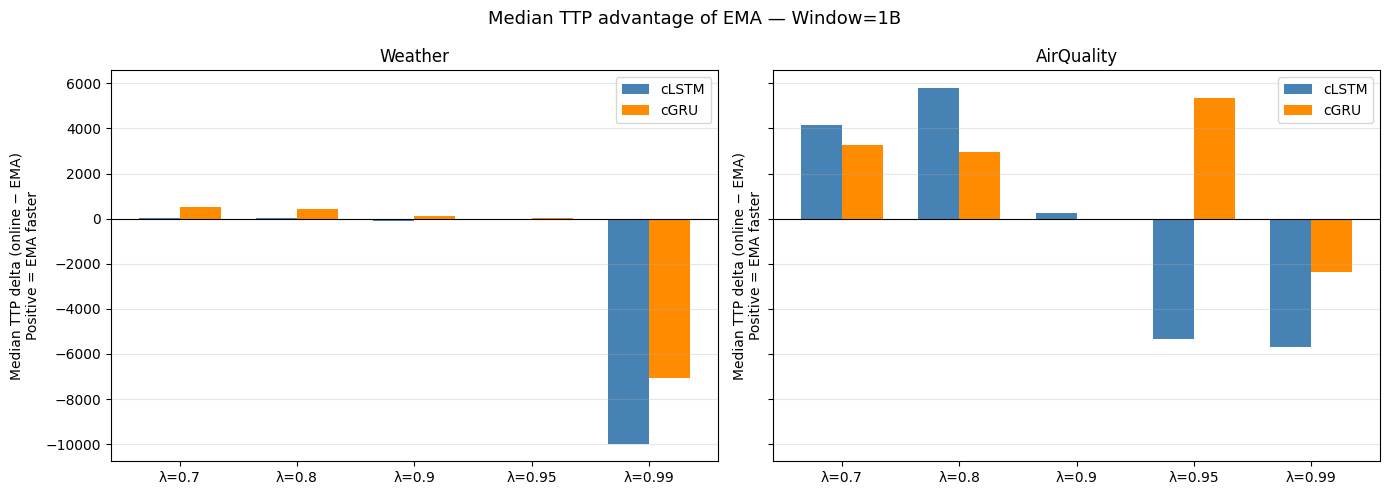

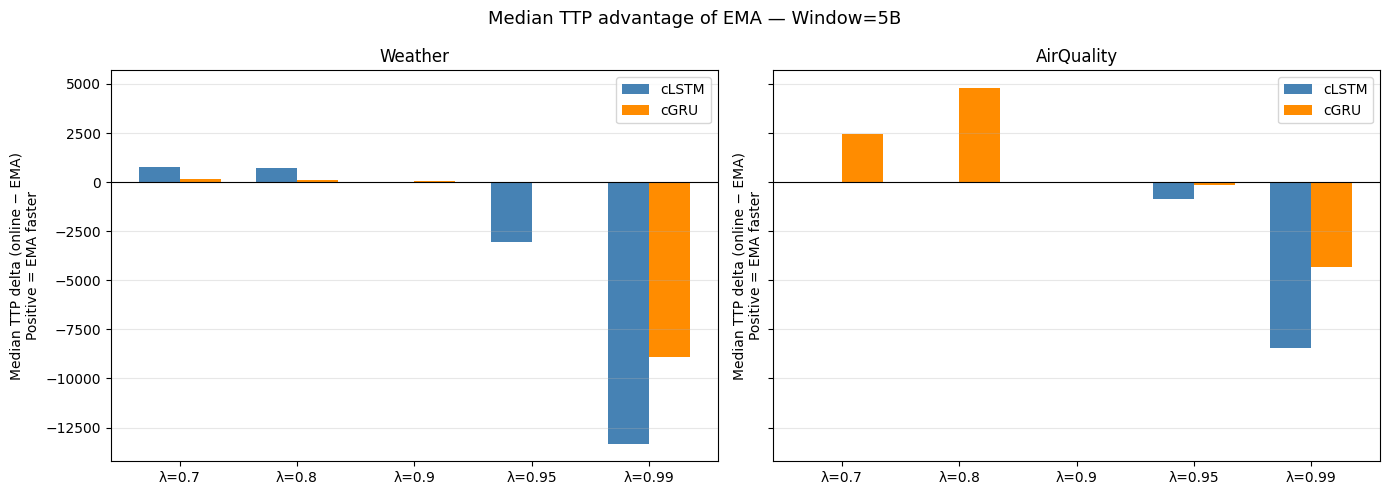

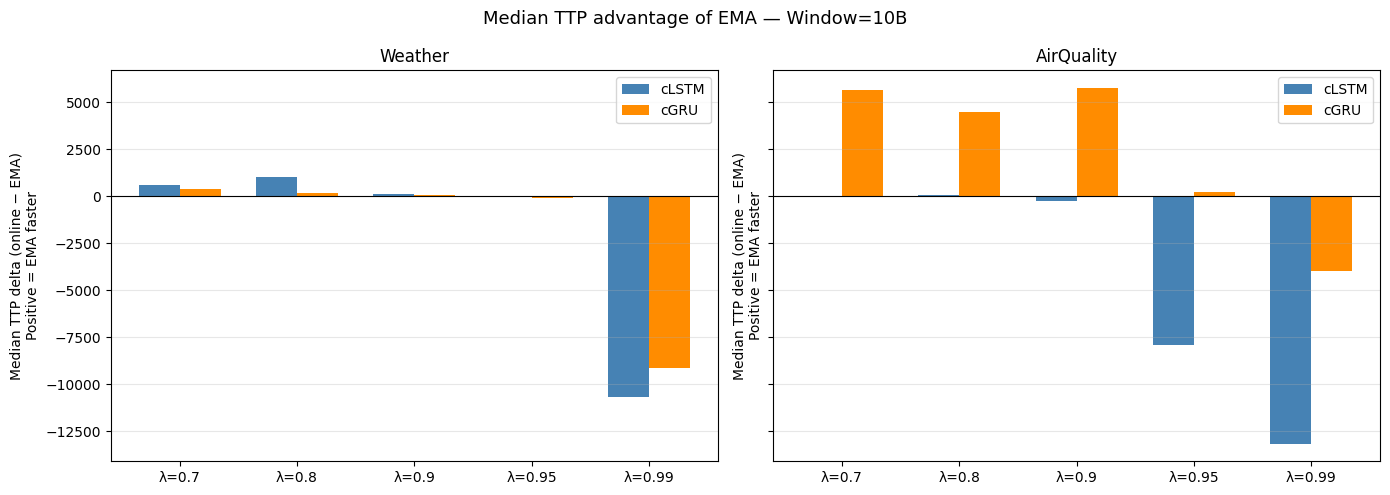

In [7]:
def collect_ttp_deltas(all_results, window_label):
    """Returns per-drift TTP deltas for a specific window."""
    records = []
    for (arch, lam, ds, win), data in all_results.items():
        if win != window_label:
            continue
        for r in data['conv']:
            if r['ttp_online'] is not None and r['ttp_ema'] is not None:
                records.append({
                    'Arch': arch, 'λ': lam, 'Dataset': ds,
                    'transition': f"C{r['concept_from']}→C{r['concept_to']}",
                    'delta': r['ttp_online'] - r['ttp_ema']
                })
    return pd.DataFrame(records)

# One bar chart figure per window
for window_label in ['1B', '5B', '10B']:
    deltas_df_w = collect_ttp_deltas(all_results, window_label)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, ds in zip(axes, ['Weather', 'AirQuality']):
        sub = deltas_df_w[deltas_df_w['Dataset'] == ds]
        agg = sub.groupby(['Arch', 'λ'])['delta'].median().unstack('Arch')

        x = np.arange(len(agg.index))
        width = 0.35
        ax.bar(x - width/2, agg['cLSTM'], width, label='cLSTM', color='steelblue')
        ax.bar(x + width/2, agg['cGRU'],  width, label='cGRU',  color='darkorange')
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels([f'λ={l}' for l in agg.index])
        ax.set_title(f'{ds}')
        ax.set_ylabel('Median TTP delta (online − EMA)\nPositive = EMA faster')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
    
    fig.suptitle(f'Median TTP advantage of EMA — Window={window_label}', fontsize=13)
    plt.tight_layout()
    plt.show()

# Keep one global deltas_df for later cells — use 10B as the primary
deltas_df = collect_ttp_deltas(all_results, '10B')

## **TTP vs TTSC: Real convergence analysis**
For each concept drift, we analyse the TTSC (Time-To-Stable-Convergence): the first sample where rolling kappa stays at orabove `ratio` × shared_max for at least `stability_window` consecutive samples.
Both models are evaluated against the same target (the higher of their two within-concept maximum kappa values, scaled by `ratio`) for fair comparison.
    
It is used as a complementary metric to TTP: TTP measures first attainment of recovery (which can be a transient spike), while TTSC measures genuine convergence to a stable predictive regime. The gap between TTP wins and TTSC wins reveals how much of EMA's apparent convergence advantage corresponds to sustained recovery vs. brief threshold crossings.

In [16]:
# Compute stable convergence per window size
# stability_window must match K_ROLLING_WINDOW for each window: 128, 640, 1280
stability_windows = {'1B': 128, '5B': 640, '10B': 1280}

stable_results = {}
for (arch, lam, ds, win), data in all_results.items():
    sw_stab = stability_windows[win]
    stable_results[(arch, lam, ds, win)] = stable_convergence_per_drift(
        data['k_online'], data['k_ema'], data['tasks'],
        ratio=0.9, stability_window=sw_stab
    )

# Build TTP vs TTSC comparison table per window
for window_label in ['1B', '5B', '10B']:
    rows = []
    for (arch, lam, ds, win), conv in stable_results.items():
        if win != window_label:
            continue
        base_conv = all_results[(arch, lam, ds, win)]['conv']

        ttp_pairs = [(r['ttp_online'], r['ttp_ema']) for r in base_conv
                      if r['ttp_online'] is not None and r['ttp_ema'] is not None]
        ttsc_pairs = [(r['ttsc_online'], r['ttsc_ema']) for r in conv
                       if r['ttsc_online'] is not None and r['ttsc_ema'] is not None]

        if ttp_pairs:
            med_online = np.median([p[0] for p in ttp_pairs])
            med_ema    = np.median([p[1] for p in ttp_pairs])
            ttp_med_delta = med_online - med_ema
        else:
            ttp_med_delta = np.nan
        if ttsc_pairs:
            med_online = np.median([p[0] for p in ttsc_pairs])
            med_ema    = np.median([p[1] for p in ttsc_pairs])
            ttsc_med_delta = med_online - med_ema
        else:
            ttsc_med_delta = np.nan

        n_stable_online = sum(1 for r in conv if r['ttsc_online'] is not None)
        n_stable_ema    = sum(1 for r in conv if r['ttsc_ema']    is not None)

        rows.append({
            'Arch': arch, 'λ': lam, 'Dataset': ds,
            'TTP delta (median)':  f"{ttp_med_delta:+.0f}"  if not np.isnan(ttp_med_delta)  else 'N/A',
            'TTSC delta (median)': f"{ttsc_med_delta:+.0f}" if not np.isnan(ttsc_med_delta) else 'N/A',
            'Online stable on':    f"{n_stable_online}/7 drifts",
            'EMA stable on':       f"{n_stable_ema}/7 drifts",
        })

    df_stable = pd.DataFrame(rows).sort_values(['λ', 'Dataset', 'Arch']).reset_index(drop=True)
    new_rows = []
    prev_lambda = None
    for _, row in df_stable.iterrows():
        if prev_lambda is not None and row['λ'] != prev_lambda:
            new_rows.append({col: '' for col in df_stable.columns})
        new_rows.append(row.to_dict())
        prev_lambda = row['λ']
    df_stable_sep = pd.DataFrame(new_rows)

    print(f"\n{'='*100}")
    print(f"  TTP vs TTSC — Window={window_label}")
    print(f"{'='*100}")
    print(tabulate(df_stable_sep, headers='keys', tablefmt='grid', showindex=False,
                    colalign=('left',)*3 + ('center',)*4))


  TTP vs TTSC — Window=1B
+--------+------+------------+----------------------+-----------------------+--------------------+-----------------+
| Arch   | λ    | Dataset    |  TTP delta (median)  |  TTSC delta (median)  |  Online stable on  |  EMA stable on  |
+========+======+============+======================+=======================+====================+=================+
| cGRU   | 0.7  | AirQuality |        +1732         |          N/A          |     0/7 drifts     |   0/7 drifts    |
+--------+------+------------+----------------------+-----------------------+--------------------+-----------------+
| cLSTM  | 0.7  | AirQuality |        +6370         |          N/A          |     0/7 drifts     |   0/7 drifts    |
+--------+------+------------+----------------------+-----------------------+--------------------+-----------------+
| cGRU   | 0.7  | Weather    |          +1          |          +24          |     2/7 drifts     |   4/7 drifts    |
+--------+------+------------+-------

In [10]:
for window_label in ['1B', '5B', '10B']:
    print(f"\n=== Slope deltas — Window={window_label} ===")
    for (arch, lam, ds, win), data in all_results.items():
        if win != window_label:
            continue
        conv = data['conv']
        mean_slope_online = np.nanmean([r['slope_online'] for r in conv])
        mean_slope_ema    = np.nanmean([r['slope_ema']    for r in conv])
        slope_delta = mean_slope_ema - mean_slope_online
        print(f"{arch} | λ={lam} | {ds}: slope delta = {slope_delta:+.5f}")


=== Slope deltas — Window=1B ===
cLSTM | λ=0.7 | Weather: slope delta = -0.00070
cLSTM | λ=0.7 | AirQuality: slope delta = -0.00029
cLSTM | λ=0.8 | Weather: slope delta = -0.00087
cLSTM | λ=0.8 | AirQuality: slope delta = -0.00045
cLSTM | λ=0.9 | Weather: slope delta = -0.00119
cLSTM | λ=0.9 | AirQuality: slope delta = -0.00036
cLSTM | λ=0.95 | Weather: slope delta = -0.00137
cLSTM | λ=0.95 | AirQuality: slope delta = -0.00040
cLSTM | λ=0.99 | Weather: slope delta = -0.00133
cLSTM | λ=0.99 | AirQuality: slope delta = -0.00042
cGRU | λ=0.7 | Weather: slope delta = -0.00084
cGRU | λ=0.7 | AirQuality: slope delta = -0.00044
cGRU | λ=0.8 | Weather: slope delta = -0.00110
cGRU | λ=0.8 | AirQuality: slope delta = -0.00045
cGRU | λ=0.9 | Weather: slope delta = -0.00144
cGRU | λ=0.9 | AirQuality: slope delta = -0.00035
cGRU | λ=0.95 | Weather: slope delta = -0.00165
cGRU | λ=0.95 | AirQuality: slope delta = -0.00020
cGRU | λ=0.99 | Weather: slope delta = -0.00158
cGRU | λ=0.99 | AirQuality: s

### **VISUALIZATION - COMPARISON BAR CHART**

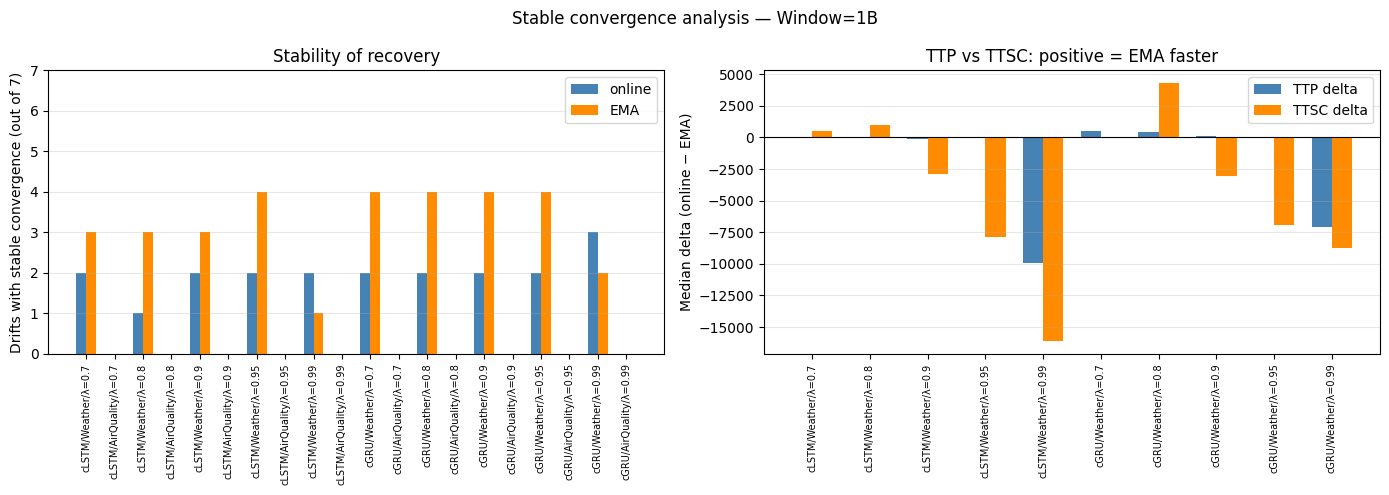

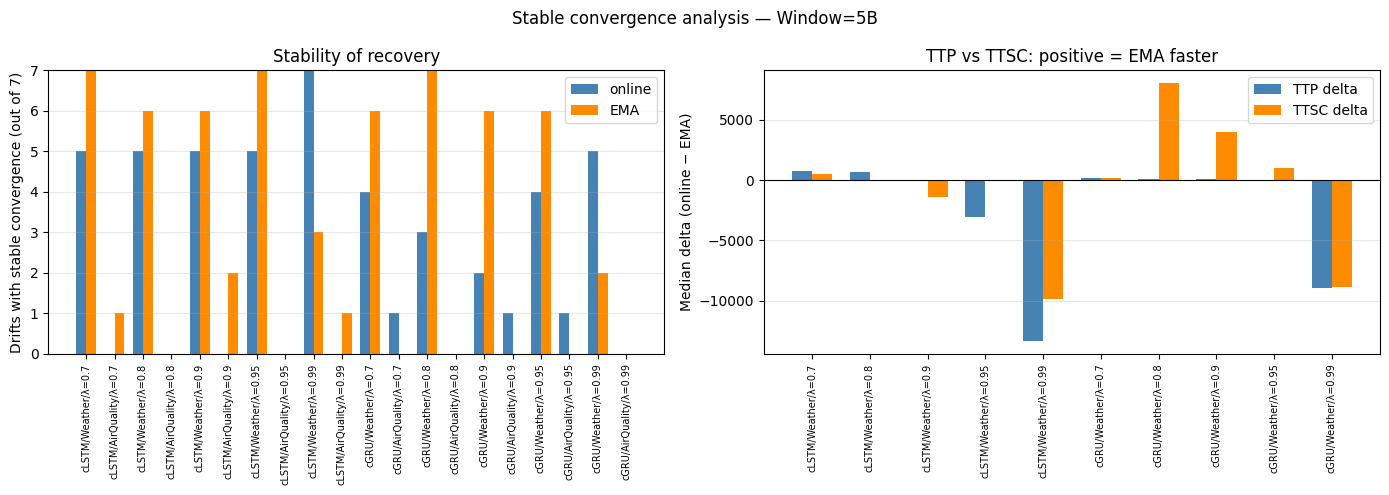

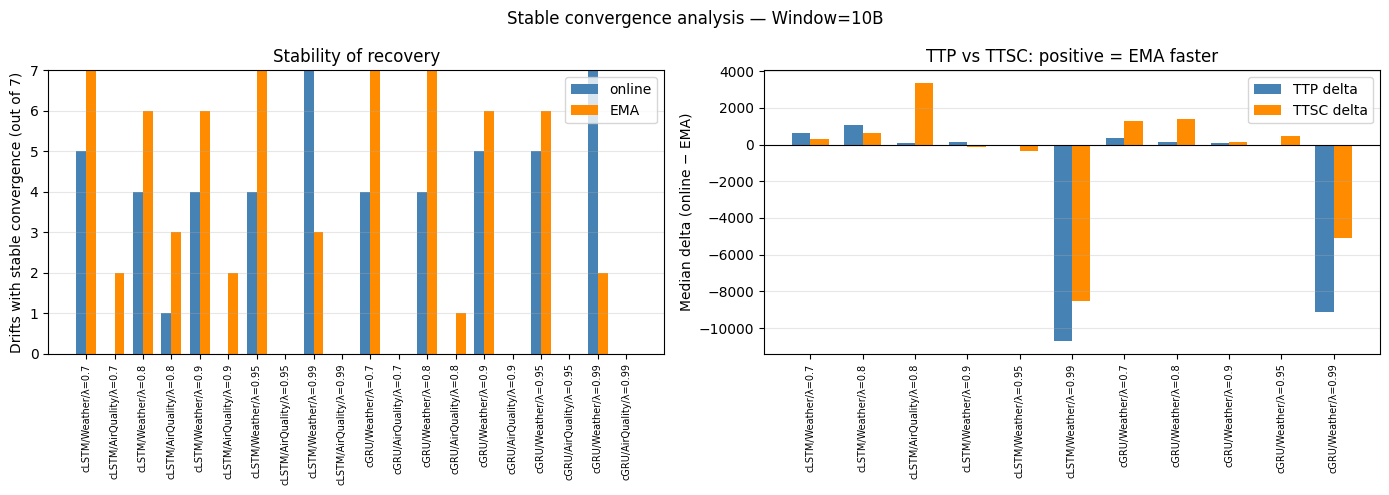

In [11]:
for window_label in ['1B', '5B', '10B']:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: stable convergence count per config
    stable_counts = []
    for (arch, lam, ds, win), conv in stable_results.items():
        if win != window_label:
            continue
        n_stable_online = sum(1 for r in conv if r['ttsc_online'] is not None)
        n_stable_ema    = sum(1 for r in conv if r['ttsc_ema']    is not None)
        stable_counts.append({
            'config': f"{arch}/{ds}/λ={lam}",
            'online': n_stable_online,
            'ema': n_stable_ema
        })
    stable_df = pd.DataFrame(stable_counts)
    x = np.arange(len(stable_df))
    width = 0.35
    axes[0].bar(x - width/2, stable_df['online'], width, label='online', color='steelblue')
    axes[0].bar(x + width/2, stable_df['ema'],    width, label='EMA',    color='darkorange')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(stable_df['config'], rotation=90, fontsize=7)
    axes[0].set_ylabel('Drifts with stable convergence (out of 7)')
    axes[0].set_title('Stability of recovery')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].set_ylim(0, 7)

    # Right: TTP vs TTSC median delta
    ttp_deltas, ttsc_deltas, labels_x = [], [], []
    for (arch, lam, ds, win), conv in stable_results.items():
        if win != window_label:
            continue
        base_conv = all_results[(arch, lam, ds, win)]['conv']
        ttp_pairs  = [(r['ttp_online'],  r['ttp_ema'])  for r in base_conv
                       if r['ttp_online']  is not None and r['ttp_ema']  is not None]
        ttsc_pairs = [(r['ttsc_online'], r['ttsc_ema']) for r in conv
                       if r['ttsc_online'] is not None and r['ttsc_ema'] is not None]
        if ttp_pairs and ttsc_pairs:
            ttp_deltas.append(np.median([p[0]-p[1] for p in ttp_pairs]))
            ttsc_deltas.append(np.median([p[0]-p[1] for p in ttsc_pairs]))
            labels_x.append(f"{arch}/{ds}/λ={lam}")

    x = np.arange(len(labels_x))
    axes[1].bar(x - width/2, ttp_deltas,  width, label='TTP delta',  color='steelblue')
    axes[1].bar(x + width/2, ttsc_deltas, width, label='TTSC delta', color='darkorange')
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels_x, rotation=90, fontsize=7)
    axes[1].set_ylabel('Median delta (online − EMA)')
    axes[1].set_title('TTP vs TTSC: positive = EMA faster')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)

    fig.suptitle(f'Stable convergence analysis — Window={window_label}', fontsize=12)
    plt.tight_layout()
    plt.show()

## FINAL ANSWER: DISTRIBUTION OF ALL TTP DELTAS

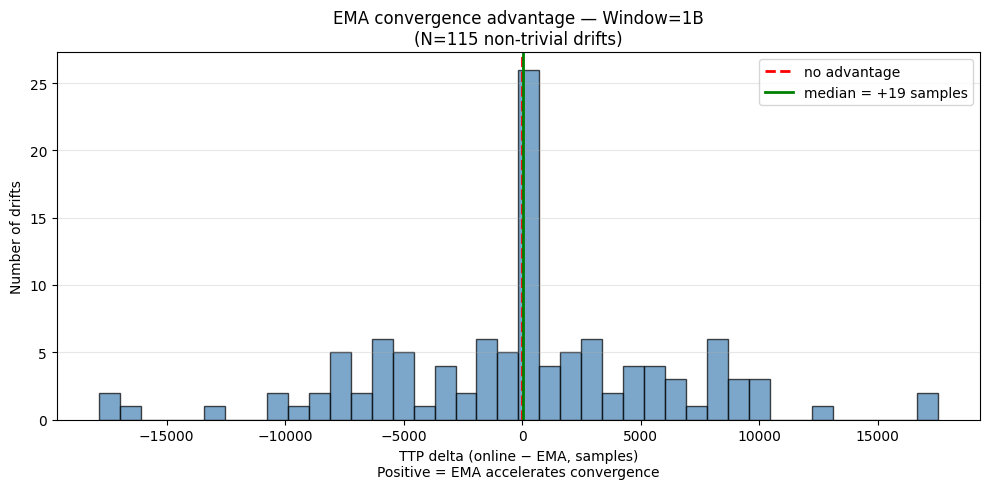


=== Window=1B: across 115 non-trivial drifts ===
  EMA faster:     61 (53.0%)
  Online faster:  54 (47.0%)
  Tied:            0 (0.0%)
  Median delta:  +19 samples
  Mean delta:    +70 samples


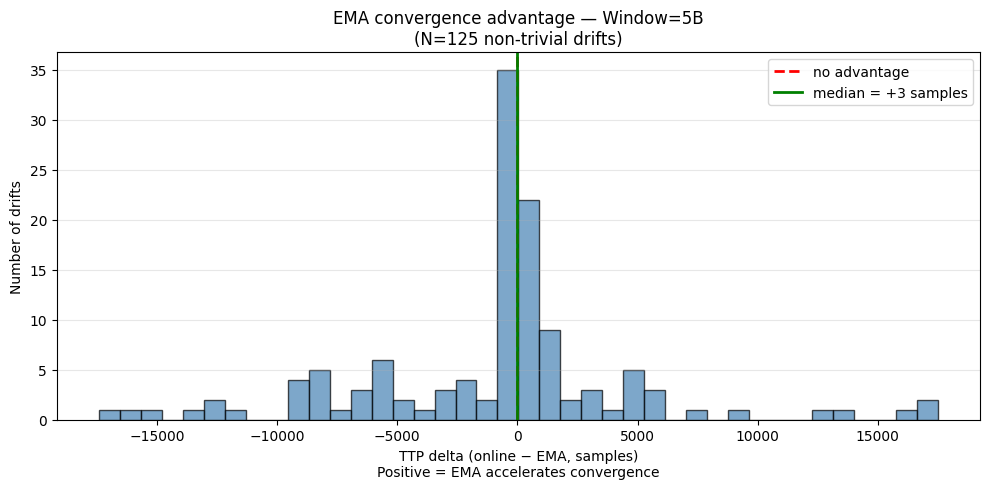


=== Window=5B: across 125 non-trivial drifts ===
  EMA faster:     65 (52.0%)
  Online faster:  60 (48.0%)
  Tied:            0 (0.0%)
  Median delta:  +3 samples
  Mean delta:    -833 samples


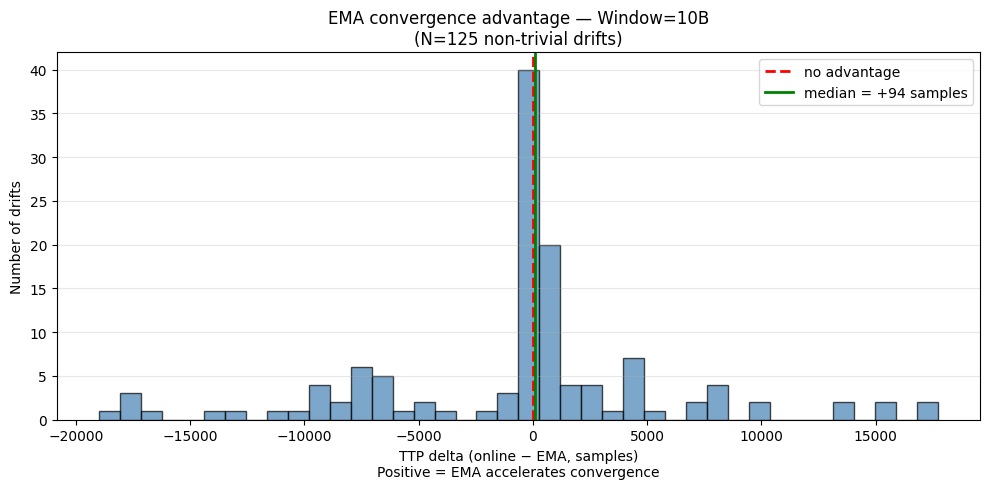


=== Window=10B: across 125 non-trivial drifts ===
  EMA faster:     77 (61.6%)
  Online faster:  48 (38.4%)
  Tied:            0 (0.0%)
  Median delta:  +94 samples
  Mean delta:    -513 samples


In [12]:
for window_label in ['1B', '5B', '10B']:
    deltas_df_w = collect_ttp_deltas(all_results, window_label)
    valid_deltas = deltas_df_w[deltas_df_w['delta'].abs() > 0]['delta'].values

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(valid_deltas, bins=40, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axvline(0, color='red', linestyle='--', label='no advantage', linewidth=2)
    ax.axvline(np.median(valid_deltas), color='green', linestyle='-',
                label=f'median = {np.median(valid_deltas):+.0f} samples', linewidth=2)
    ax.set_xlabel('TTP delta (online − EMA, samples)\nPositive = EMA accelerates convergence')
    ax.set_ylabel('Number of drifts')
    ax.set_title(f'EMA convergence advantage — Window={window_label}\n'
                  f'(N={len(valid_deltas)} non-trivial drifts)')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    n_total = len(valid_deltas)
    n_ema_faster = (valid_deltas > 0).sum()
    n_online_faster = (valid_deltas < 0).sum()
    n_tied = (valid_deltas == 0).sum()

    print(f"\n=== Window={window_label}: across {n_total} non-trivial drifts ===")
    print(f"  EMA faster:    {n_ema_faster:3d} ({100*n_ema_faster/n_total:.1f}%)")
    print(f"  Online faster: {n_online_faster:3d} ({100*n_online_faster/n_total:.1f}%)")
    print(f"  Tied:          {n_tied:3d} ({100*n_tied/n_total:.1f}%)")
    print(f"  Median delta:  {np.median(valid_deltas):+.0f} samples")
    print(f"  Mean delta:    {np.mean(valid_deltas):+.0f} samples")

## PER-DRIFT ΔTTP DISTRIBUTION

This plot shows the distribution of TTP deltas across all non-trivial drift transitions.

The linear scale highlights that most drifts are close to zero, while the symlog scale makes the extreme positive and negative tails visible.
Positive ΔTTP means EMA reaches the threshold earlier; negative ΔTTP means the online model reaches it earlier.

The goal is not to claim stable convergence, but to show that EMA strongly reshapes transient threshold-crossing behaviour in a transition-dependent way.

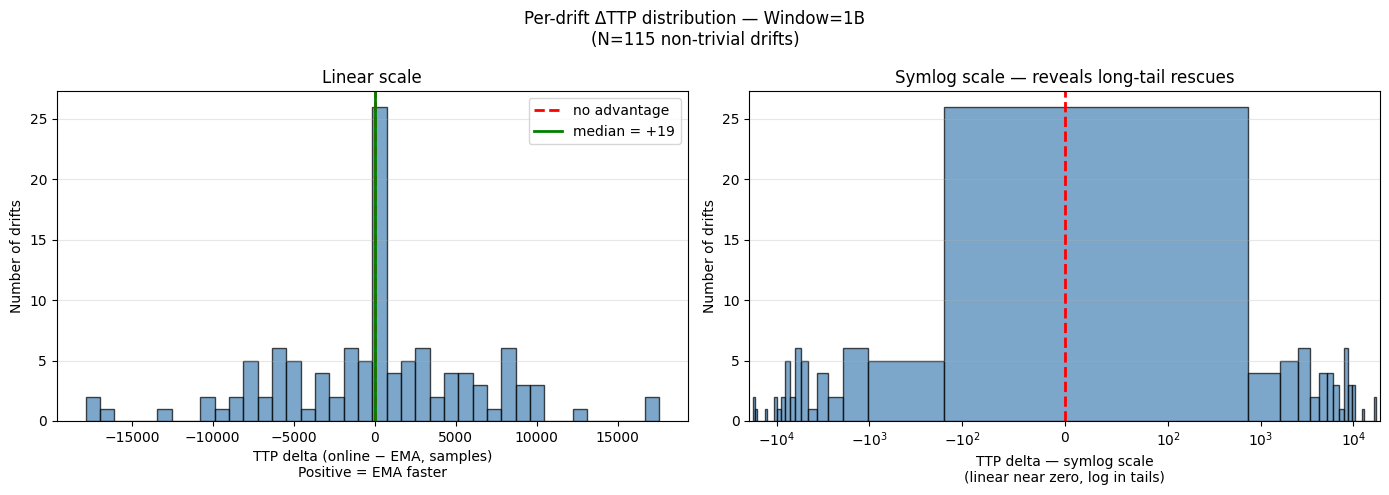


=== Window=1B: top 8 extreme deltas ===

Top 8 EMA wins (largest positive TTP delta):
 Arch    λ    Dataset transition  delta
 cGRU 0.95 AirQuality      C4→C5  17542
cLSTM 0.90 AirQuality      C3→C4  17481
cLSTM 0.80 AirQuality      C3→C4  13037
 cGRU 0.90 AirQuality      C6→C7   9938
 cGRU 0.95 AirQuality      C6→C7   9933
cLSTM 0.70 AirQuality      C3→C4   9625
cLSTM 0.90    Weather      C2→C3   8942
cLSTM 0.80    Weather      C2→C3   8936

Top 8 Online wins (largest negative TTP delta):
 Arch    λ    Dataset transition  delta
 cGRU 0.99    Weather      C6→C7 -17854
 cGRU 0.99 AirQuality      C4→C5 -17052
cLSTM 0.99    Weather      C5→C6 -16159
cLSTM 0.99 AirQuality      C2→C3 -13201
cLSTM 0.99    Weather      C3→C4  -9977
cLSTM 0.99    Weather      C6→C7  -9969
cLSTM 0.99    Weather      C1→C2  -9425
cLSTM 0.99    Weather      C2→C3  -8935

Aggregate for window=1B:
  EMA faster:     61 (53.0%)
  Online faster:  54 (47.0%)
  Median delta:  +19 samples
  Mean delta:    +70 samples


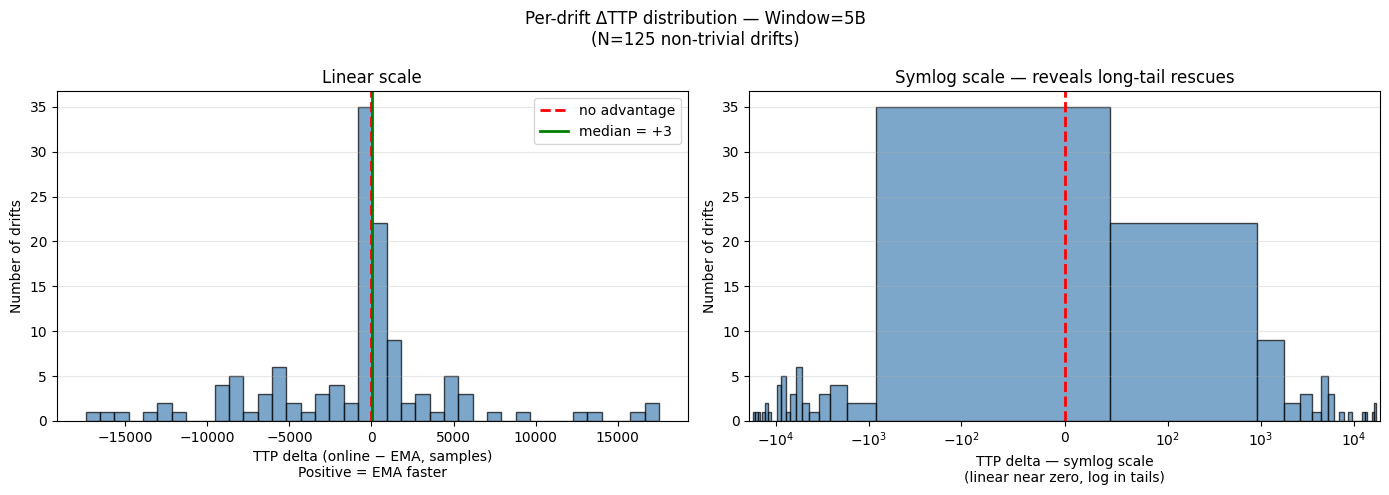


=== Window=5B: top 8 extreme deltas ===

Top 8 EMA wins (largest positive TTP delta):
 Arch   λ    Dataset transition  delta
cLSTM 0.9 AirQuality      C4→C5  17507
 cGRU 0.7 AirQuality      C4→C5  16860
cLSTM 0.8 AirQuality      C4→C5  16075
 cGRU 0.8 AirQuality      C2→C3  13559
cLSTM 0.8 AirQuality      C3→C4  12688
cLSTM 0.7 AirQuality      C3→C4   9558
cLSTM 0.9 AirQuality      C3→C4   7386
cLSTM 0.7    Weather      C5→C6   5604

Top 8 Online wins (largest negative TTP delta):
 Arch    λ    Dataset transition  delta
 cGRU 0.99    Weather      C6→C7 -17420
cLSTM 0.99    Weather      C6→C7 -16282
cLSTM 0.99    Weather      C5→C6 -15160
cLSTM 0.99 AirQuality      C2→C3 -13892
cLSTM 0.99 AirQuality      C7→C8 -12894
cLSTM 0.99 AirQuality      C6→C7 -12712
cLSTM 0.99    Weather      C1→C2 -11470
 cGRU 0.99 AirQuality      C3→C4  -9473

Aggregate for window=5B:
  EMA faster:     65 (52.0%)
  Online faster:  60 (48.0%)
  Median delta:  +3 samples
  Mean delta:    -833 samples


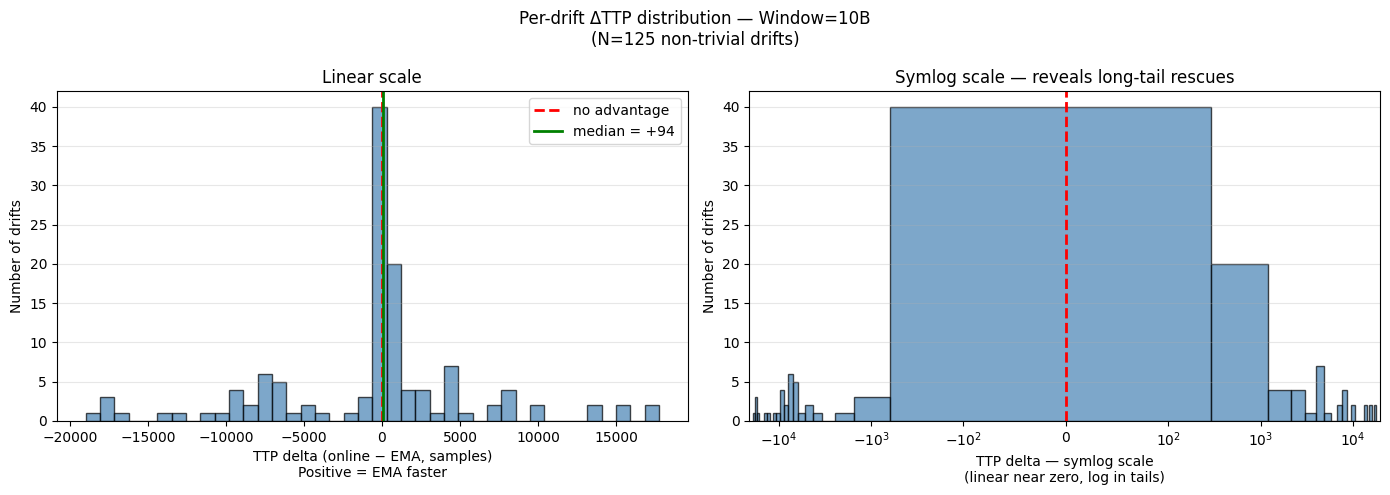


=== Window=10B: top 8 extreme deltas ===

Top 8 EMA wins (largest positive TTP delta):
 Arch    λ    Dataset transition  delta
 cGRU 0.70 AirQuality      C4→C5  17735
cLSTM 0.90 AirQuality      C4→C5  17164
 cGRU 0.70 AirQuality      C3→C4  15482
 cGRU 0.80 AirQuality      C3→C4  15481
 cGRU 0.90 AirQuality      C7→C8  13663
 cGRU 0.80 AirQuality      C2→C3  13316
cLSTM 0.99 AirQuality      C1→C2   9952
 cGRU 0.95 AirQuality      C3→C4   9487

Top 8 Online wins (largest negative TTP delta):
 Arch    λ    Dataset transition  delta
cLSTM 0.99 AirQuality      C7→C8 -18990
cLSTM 0.99 AirQuality      C3→C4 -17668
 cGRU 0.99 AirQuality      C4→C5 -17549
 cGRU 0.99    Weather      C6→C7 -17515
cLSTM 0.99    Weather      C6→C7 -16249
cLSTM 0.99 AirQuality      C6→C7 -13819
cLSTM 0.99 AirQuality      C2→C3 -13160
 cGRU 0.95 AirQuality      C1→C2 -11435

Aggregate for window=10B:
  EMA faster:     77 (61.6%)
  Online faster:  48 (38.4%)
  Median delta:  +94 samples
  Mean delta:    -513 samples

In [13]:
# Per-drift TTP delta histograms — one figure per window size

for window_label in ['1B', '5B', '10B']:
    deltas_df_w = collect_ttp_deltas(all_results, window_label)
    valid_deltas = deltas_df_w[deltas_df_w['delta'].abs() > 0]['delta'].values
    
    if len(valid_deltas) == 0:
        print(f"\n=== Window={window_label}: no non-trivial drifts ===")
        continue
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Linear scale — shows central mass clearly
    ax = axes[0]
    ax.hist(valid_deltas, bins=40, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='no advantage')
    ax.axvline(np.median(valid_deltas), color='green', linestyle='-', linewidth=2,
                label=f'median = {np.median(valid_deltas):+.0f}')
    ax.set_xlabel('TTP delta (online − EMA, samples)\nPositive = EMA faster')
    ax.set_ylabel('Number of drifts')
    ax.set_title('Linear scale')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Symlog scale — reveals long-tail extreme deltas
    ax = axes[1]
    ax.hist(valid_deltas, bins=40, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axvline(0, color='red', linestyle='--', linewidth=2)
    ax.set_xscale('symlog', linthresh=100)
    ax.set_xlabel('TTP delta — symlog scale\n(linear near zero, log in tails)')
    ax.set_ylabel('Number of drifts')
    ax.set_title('Symlog scale — reveals long-tail rescues')
    ax.grid(axis='y', alpha=0.3)
    
    fig.suptitle(f'Per-drift ΔTTP distribution — Window={window_label}\n'
                  f'(N={len(valid_deltas)} non-trivial drifts)', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Companion: top 8 EMA wins and 8 online wins
    top_n = 8
    top_ema    = deltas_df_w.nlargest(top_n,  'delta')[['Arch', 'λ', 'Dataset', 'transition', 'delta']]
    top_online = deltas_df_w.nsmallest(top_n, 'delta')[['Arch', 'λ', 'Dataset', 'transition', 'delta']]
    
    print(f"\n=== Window={window_label}: top {top_n} extreme deltas ===")
    print(f"\nTop {top_n} EMA wins (largest positive TTP delta):")
    print(top_ema.to_string(index=False))
    
    print(f"\nTop {top_n} Online wins (largest negative TTP delta):")
    print(top_online.to_string(index=False))
    
    # Quick aggregate at end of each window section
    n_total = len(valid_deltas)
    n_ema_faster = (valid_deltas > 0).sum()
    n_online_faster = (valid_deltas < 0).sum()
    
    print(f"\nAggregate for window={window_label}:")
    print(f"  EMA faster:    {n_ema_faster:3d} ({100*n_ema_faster/n_total:.1f}%)")
    print(f"  Online faster: {n_online_faster:3d} ({100*n_online_faster/n_total:.1f}%)")
    print(f"  Median delta:  {np.median(valid_deltas):+.0f} samples")
    print(f"  Mean delta:    {np.mean(valid_deltas):+.0f} samples")

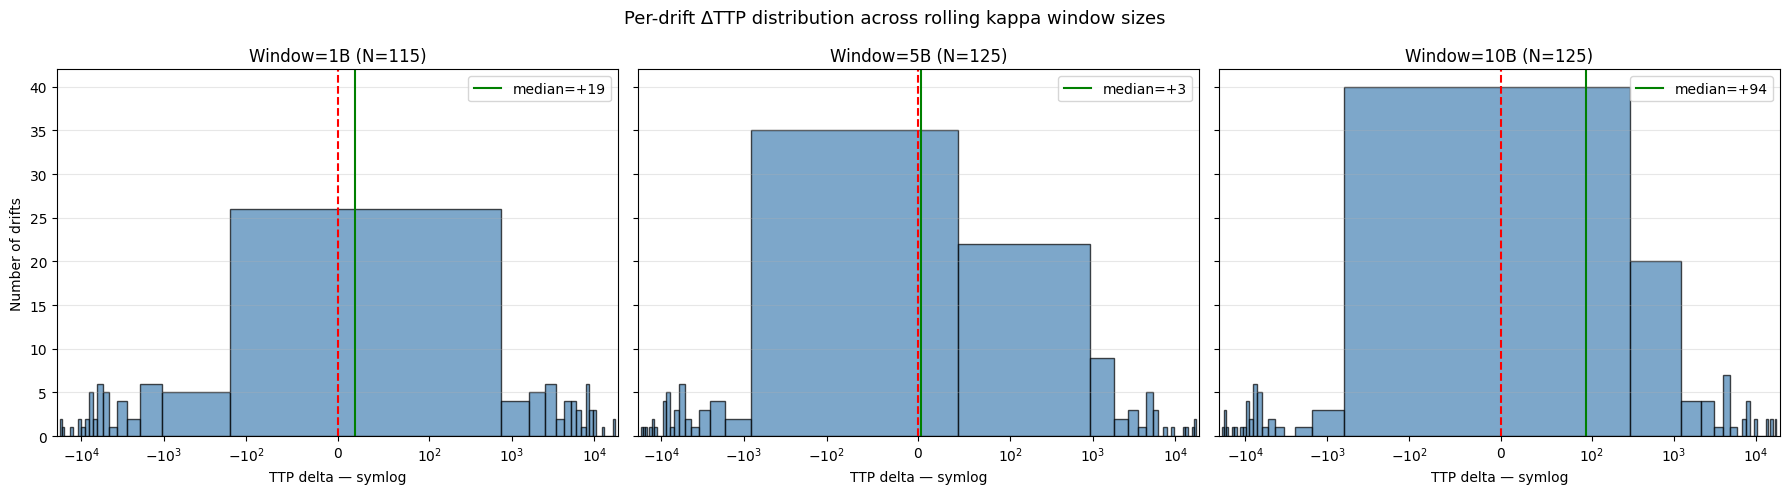

In [14]:
# Side-by-side comparison: ΔTTP distribution at all three windows on one figure

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, window_label in zip(axes, ['1B', '5B', '10B']):
    deltas_df_w = collect_ttp_deltas(all_results, window_label)
    valid_deltas = deltas_df_w[deltas_df_w['delta'].abs() > 0]['delta'].values
    
    if len(valid_deltas) > 0:
        ax.hist(valid_deltas, bins=40, color='steelblue', alpha=0.7, edgecolor='black')
        ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
        ax.axvline(np.median(valid_deltas), color='green', linestyle='-', linewidth=1.5,
                    label=f'median={np.median(valid_deltas):+.0f}')
        ax.set_xscale('symlog', linthresh=100)
        ax.set_title(f'Window={window_label} (N={len(valid_deltas)})')
        ax.set_xlabel('TTP delta — symlog')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Number of drifts')
fig.suptitle('Per-drift ΔTTP distribution across rolling kappa window sizes', fontsize=13)
plt.tight_layout()
plt.show()